<a href="https://colab.research.google.com/github/anikitin52/dsp-seminars/blob/lab4/seminars/4_Nikitin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


Тип шума        | Среднее      | Дисперсия
---------------------------------------------
Белый шум       |     0.045084 | 0.976576
Розовый шум     |     0.000000 | 1.000000
Красный шум     |     0.000000 | 1.000000


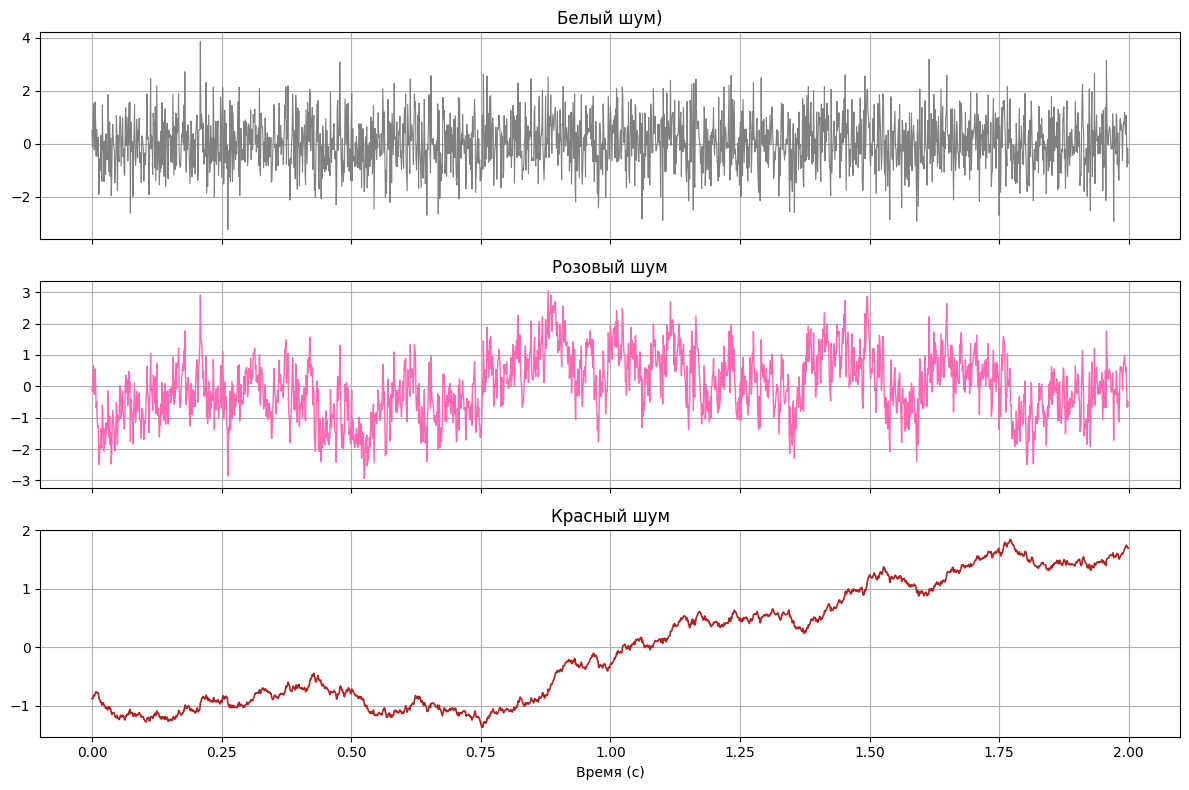

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1000       # Частота дискретизации, Гц
T = 2           # Длительность, с
N = int(fs * T) # Количество отсчетов
t = np.arange(N) / fs

np.random.seed(42)

# Гауссов шум с нулевым средним и дисперсией 1
white_noise = np.random.randn(N)



# Прямое БПФ от белого шума
X_white = np.fft.rfft(white_noise)
freqs = np.fft.rfftfreq(N, d=1/fs)

filter_func = np.zeros_like(freqs)
filter_func[1:] = 1 / np.sqrt(freqs[1:])

# Применяем фильтр и делаем обратное БПФ
pink_noise = np.fft.irfft(X_white * filter_func, n=N)

pink_noise = (pink_noise - np.mean(pink_noise)) / np.std(pink_noise)


red_noise = np.cumsum(white_noise)

# Нормализация
red_noise = (red_noise - np.mean(red_noise)) / np.std(red_noise)


# Вычисление статистик
signals = {
    "Белый шум": white_noise,
    "Розовый шум": pink_noise,
    "Красный шум": red_noise
}

print(f"{'Тип шума':<15} | {'Среднее':<12} | {'Дисперсия'}")
print("-" * 45)
for name, sig in signals.items():
    mean_val = np.mean(sig)
    var_val = np.var(sig)
    print(f"{name:<15} | {mean_val:>12.6f} | {var_val:.6f}")


fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, white_noise, color='gray', linewidth=0.8)
axs[0].set_title('Белый шум)')
axs[0].grid(True)

axs[1].plot(t, pink_noise, color='hotpink', linewidth=1)
axs[1].set_title('Розовый шум')
axs[1].grid(True)

axs[2].plot(t, red_noise, color='firebrick', linewidth=1.2)
axs[2].set_title('Красный шум')
axs[2].set_xlabel('Время (с)')
axs[2].grid(True)

plt.tight_layout()
plt.show()

**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


{На полученных графиках видим, что белый шум напоминает хаотичные колебания, значение резко меняются при переходе к следующему отсчёту, одинаковое количество низких и высоких частот. Гафик розового шума изменяется медленнее, он более структурирован, здесь больше низких частот. Последний график для красного шума изменяется очень плавно. По выведенной таблице видим, что средние значения близки к нулю. Дисперсия близка к единице, но сделано это искусственно: для каждого шума выполняется нормировка по среднему значению. Некоторые получившиеся характеристики отклоняются от теоретических (среднее = 0 и дисперсия = 1 в теории) на небольшие значения из-за конечной длины сигнала и случайного характера шума.}

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


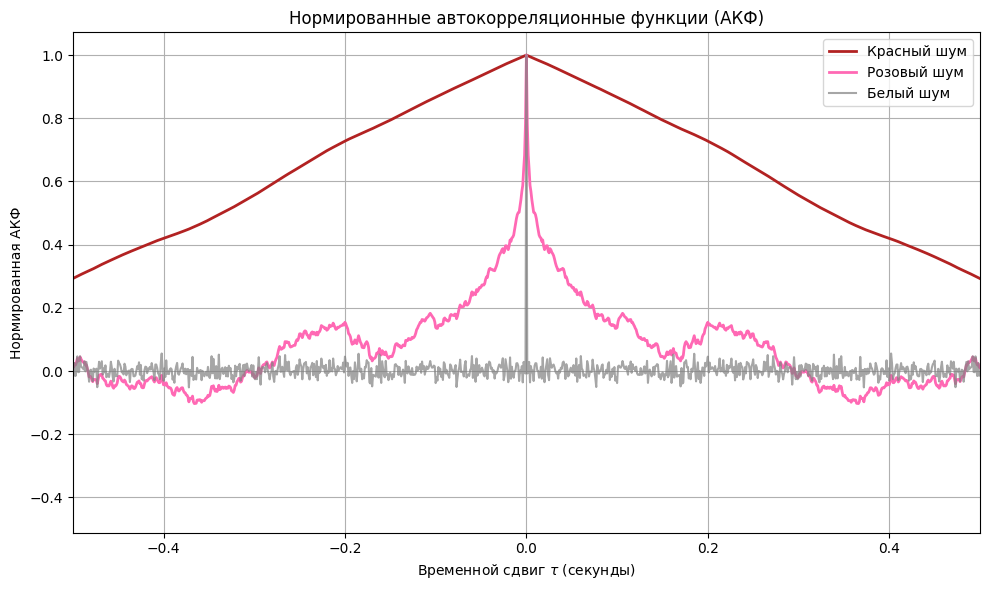

In [2]:
# Вспомогательная функция для вычисления нормированной АКФ
def get_normalized_acf(signal):
    # Вычисляем полную АКФ
    acf_full = np.correlate(signal, signal, mode='full')

    # Индекс нулевого сдвига (центр массива)
    zero_lag_index = len(signal) - 1

    # Нормируем на значение при нулевом сдвиге (чтобы максимум был равен 1)
    acf_norm = acf_full / acf_full[zero_lag_index]
    return acf_norm

# Вычисляем АКФ для каждого шума
acf_white = get_normalized_acf(white_noise)
acf_pink = get_normalized_acf(pink_noise)
acf_red = get_normalized_acf(red_noise)

# Создаем ось временных сдвигов (в секундах)
lags = np.arange(-N + 1, N)
time_lags = lags / fs

# Построение графиков
plt.figure(figsize=(10, 6))

plt.plot(time_lags, acf_red, label='Красный шум', color='firebrick', linewidth=2)
plt.plot(time_lags, acf_pink, label='Розовый шум', color='hotpink', linewidth=2)
plt.plot(time_lags, acf_white, label='Белый шум', color='gray', alpha=0.7)

plt.title('Нормированные автокорреляционные функции (АКФ)')
plt.xlabel('Временной сдвиг $\\tau$ (секунды)')
plt.ylabel('Нормированная АКФ')
plt.grid(True)
plt.legend()

plt.xlim(-0.5, 0.5)

plt.tight_layout()
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


{Белый шум имеет резкий пик в нуле и почти нулевые значения при других сдвигах, что говорит об отсутствии корреляции между соседними отсчётами. Сигнал меняется непредсказуемо и скачкообразно. Для розового шума: более широкий пик АКФ, который плавно убывает. Это означает наличие некоторой корреляции между отсчётами, поэтому сигнал получается более сглаженным. Для красного щума АКФ спадает очень медленно. Корреляция между соседними точками близка к 1. Это означает сильную зависимость каждого следующего значения от предыдущего, и сигнал получается очень плавным, без резких скачков.}

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


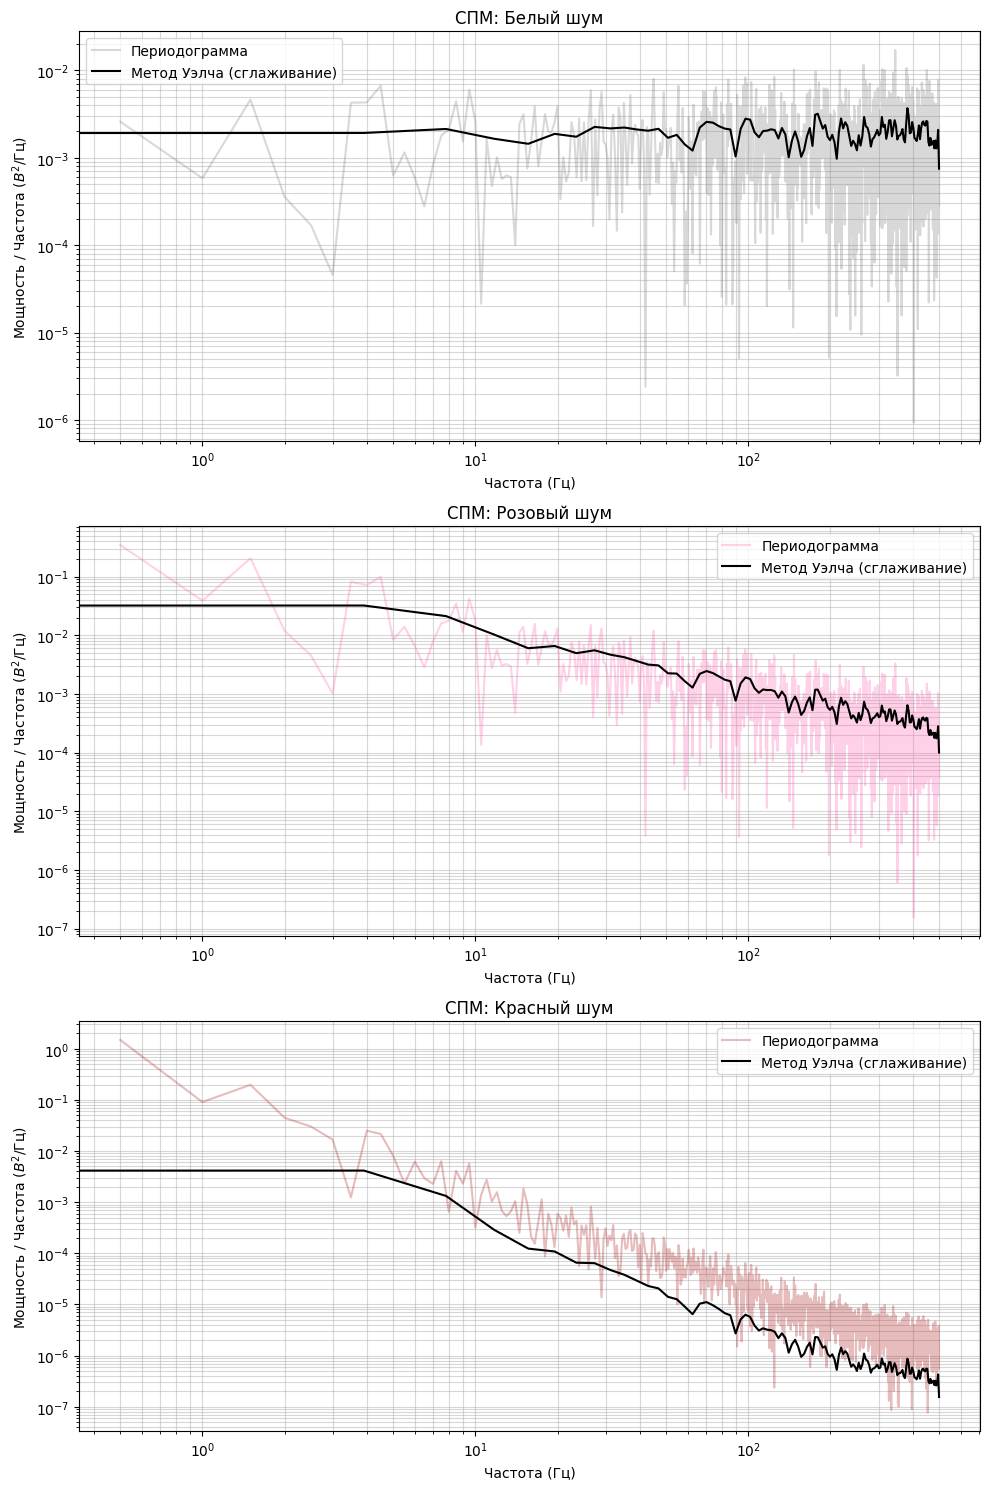

In [3]:

from scipy.signal import periodogram, welch

# Параметры для метода Уэлча
nperseg = 256
noverlap = 128

# Создаем фигуру с тремя графиками (по одному на каждый тип шума)
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

noise_data = [
    ("Белый шум", white_noise, 'gray'),
    ("Розовый шум", pink_noise, 'hotpink'),
    ("Красный шум", red_noise, 'firebrick')
]

for i, (name, signal, color) in enumerate(noise_data):
    # 1. Вычисление периодограммы
    f_per, p_per = periodogram(signal, fs)

    # 2. Оценка методом Уэлча
    f_welch, p_welch = welch(signal, fs, nperseg=nperseg, noverlap=noverlap, window='hann')

    # Построение графиков в логарифмическом масштабе

    axs[i].loglog(f_per[1:], p_per[1:], label='Периодограмма', color=color, alpha=0.3)
    axs[i].loglog(f_welch, p_welch, label='Метод Уэлча (сглаживание)', color='black', linewidth=1.5)

    axs[i].set_title(f'СПМ: {name}')
    axs[i].set_xlabel('Частота (Гц)')
    axs[i].set_ylabel('Мощность / Частота ($В^2$/Гц)')
    axs[i].grid(True, which="both", ls="-", alpha=0.5)
    axs[i].legend()

plt.tight_layout()
plt.show()

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


{Белый шум: выглядит как горизонтальная линия. Это означает, что мощность одинакова на всех частотах. Это соотвествует теоретической зависимости S(f) = константа.
Розовый шум: выглядит на графике как прямая линия, равномерно спадающая вниз (с наклоном примерно -1). Это соответсвует закону S(f)∼1/f для розового шума.
Красный шум имеет более быстрый спад S(f)∼1/f, что на графике соответствует прямой линии с наклоном около -2.}

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


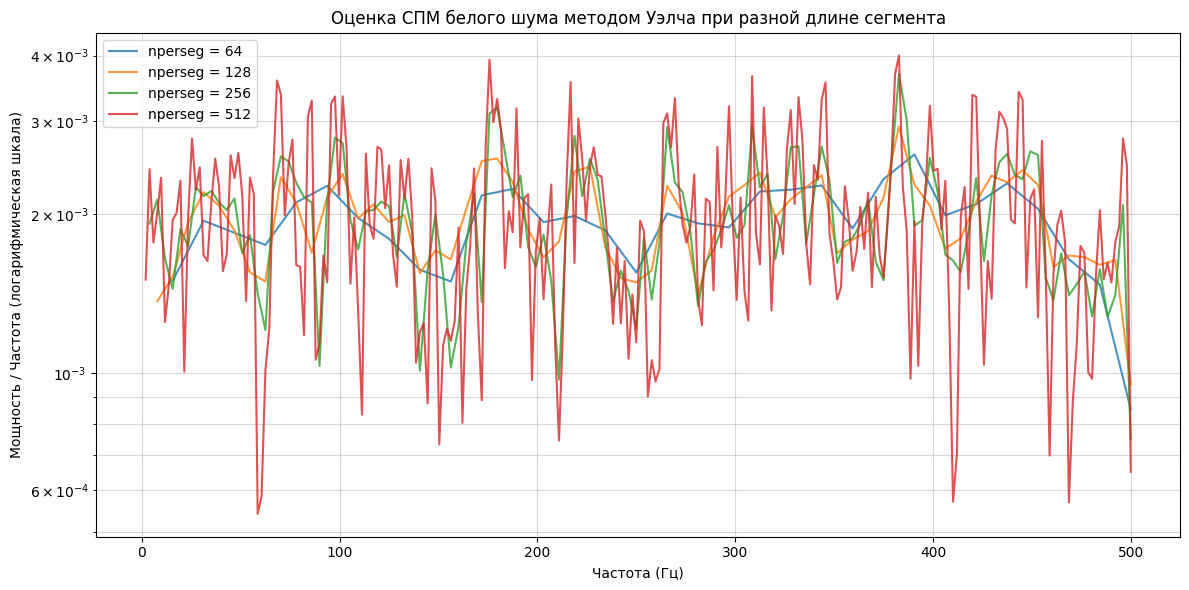

In [4]:
from scipy.signal import welch


nperseg_values = [64, 128, 256, 512]

plt.figure(figsize=(12, 6))

# Проходим в цикле по всем значениям nperseg
for n in nperseg_values:
    # noverlap = 50% от nperseg (то есть n // 2)
    f, p = welch(white_noise, fs, nperseg=n, noverlap=n//2, window='hann')

    # Строим график. semilogy делает логарифмической только ось Y
    plt.semilogy(f[1:], p[1:], label=f'nperseg = {n}', alpha=0.8)

plt.title('Оценка СПМ белого шума методом Уэлча при разной длине сегмента')
plt.xlabel('Частота (Гц)')
plt.ylabel('Мощность / Частота (логарифмическая шкала)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


{При увеличении длины сегмента улучшается частотное разрешение (пики становятся уже), но оценка спектра становится менее гладкой (возрастает разброс). При уменьшении длины сегмента, наоборот, спектр сглаживается, но теряется детализация по частоте.}

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

In [5]:


# Параметры
fs = 1000
T = 2
N = int(fs * T)
t = np.arange(N) / fs
lags = np.arange(-N + 1, N) / fs
variances = [0.1, 1.0, 10.0] # Значения дисперсии

np.random.seed(42)

# Розовый (базовый)
X_white = np.fft.rfft(np.random.randn(N))
freqs = np.fft.rfftfreq(N, d=1/fs)
filt = np.zeros_like(freqs)
filt[1:] = 1 / np.sqrt(freqs[1:])
base_pink = np.fft.irfft(X_white * filt, n=N)
base_pink = (base_pink - np.mean(base_pink)) / np.std(base_pink) # Нормируем дисперсию к 1

# Красный (базовый)
base_red = np.cumsum(np.random.randn(N))
base_red = (base_red - np.mean(base_red)) / np.std(base_red) # Нормируем дисперсию к 1

noises = {
    "Белый шум": base_white,
    "Розовый шум": base_pink,
    "Красный шум": base_red
}

for name, base_sig in noises.items():
    fig, axs = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Зависимость характеристик от дисперсии: {name}', fontsize=14, fontweight='bold')

    for var in variances:
        # Умножаем базовый сигнал на стандартное отклонение (корень из дисперсии)
        std_dev = np.sqrt(var)
        sig = base_sig * std_dev

        # 1. Временная реализация
        axs[0].plot(t, sig, label=f'var = {var}', alpha=0.8)

        # 2. Ненормированная АКФ
        acf = np.correlate(sig, sig, mode='full') / N
        axs[1].plot(lags, acf, label=f'var = {var}', alpha=0.8)

        # 3. СПМ (Метод Уэлча)
        f_welch, p_welch = welch(sig, fs, nperseg=256, noverlap=128, window='hann')
        axs[2].loglog(f_welch, p_welch, label=f'var = {var}', alpha=0.8)

    # Оформление осей
    axs[0].set_title('Временная реализация')
    axs[0].set_xlabel('Время (с)')
    axs[0].set_ylabel('Амплитуда')

    axs[1].set_title('Ненормированная АКФ')
    axs[1].set_xlabel('Сдвиг $\\tau$ (с)')
    axs[1].set_ylabel('АКФ')
    axs[1].set_xlim(-0.5, 0.5) # Сужаем для наглядности

    axs[2].set_title('СПМ (Метод Уэлча)')
    axs[2].set_xlabel('Частота (Гц)')
    axs[2].set_ylabel('Мощность / Частота')

    for ax in axs:
        ax.grid(True, which="both", ls="-", alpha=0.5)
        ax.legend()

    plt.tight_layout()
    plt.show()

NameError: name 'base_white' is not defined

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


{При изменении дисперсии меняется только масштаб сигнала, но не его структура.
Во временной области увеличивается разброс амплитуды (сигнал становится “шумнее” по величине). В АКФ форма остаётся той же, но значения увеличиваются пропорционально дисперсии. В СПМ спектр просто поднимается вверх, но его наклон (зависимость от частоты) не меняется.}

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


In [ ]:
fs = 1000
T = 2
N = int(fs * T)
t = np.arange(N) / fs
f_true = 110  # Истинная частота
A = 1         # Амплитуда синусоиды

np.random.seed(42)  # фиксируем

results = []
# Список SNR для исследования
snr_values = [10, 0, -10, -20]

plt.figure(figsize=(12, 10))

for i, snr in enumerate(snr_values, 1):
    # 1. Расчет мощностей
    p_signal = (A**2) / 2
    p_noise = p_signal / (10**(snr / 10))

    # 2. Генерация сигнала
    target_signal = A * np.sin(2 * np.pi * f_true * t)
    noise = np.sqrt(p_noise) * np.random.randn(N)
    full_signal = target_signal + noise

    # 3. Оценка СПМ методом Уэлча
    f, p = welch(full_signal, fs, nperseg=512, noverlap=256)

    # Поиск частоты пика
    peak_idx = np.argmax(p)
    f_est = f[peak_idx]

    results.append((snr, f_est))
    # 4. Визуализация
    plt.subplot(len(snr_values), 1, i)
    plt.semilogy(f, p, color='blue', label=f'SNR = {snr} дБ')
    plt.axvline(f_true, color='red', linestyle='--', alpha=0.5, label=f'Истина (110 Гц)')
    plt.scatter(f_est, p[peak_idx], color='black', zorder=5, label=f'Пик: {f_est:.1f} Гц')

    plt.ylabel('СПМ (В²/Гц)')
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend(loc='upper right')
    if i == len(snr_values):
        plt.xlabel('Частота (Гц)')

plt.tight_layout()
plt.show()

print("SNR (дБ) | Оценка частоты | Ошибка")
for snr, f_est in results:
    print(f"{snr:>8} | {f_est:>16.2f} | {abs(f_est - f_true):.2f}")

**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


{На графиках видно, что при уменьшении SNR пик на спектре постепенно становится менее выраженным. При высоком SNR он чётко выделяется над шумом, при SNR -10 дБ — ещё различим, но менее заметен. При низком SNR пик слился с шумом и сместился. Получается, уверенно обнаружить визуально пик ещё можно при SNR -10 дБ, а дальше уже нет.}

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


In [ ]:

fs = 1000
T = 1
N = int(fs * T)
t = np.arange(N) / fs

f1, f2 = 100, 110   # две частоты
A = 1               # амплитуды
noise_var = 0.1     # дисперсия шума

np.random.seed(42)


signal = (A * np.sin(2 * np.pi * f1 * t) +
          A * np.sin(2 * np.pi * f2 * t))

noise = np.sqrt(noise_var) * np.random.randn(N)
x = signal + noise


segment_lengths = [128, 256, 512]

plt.figure(figsize=(10, 7))

for seg in segment_lengths:
    f, pxx = welch(x, fs=fs, nperseg=seg, noverlap=seg//2, window='hann')

    plt.semilogy(f, pxx, label=f'nperseg = {seg}')

# отметим истинные частоты
plt.axvline(f1, linestyle='--', color='black', alpha=0.6, label='100 Гц')
plt.axvline(f2, linestyle=':', color='black', alpha=0.6, label='110 Гц')

plt.title('Разрешение двух близких частот (метод Уэлча)')
plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for seg in segment_lengths:
    df = fs / seg
    print(f"nperseg = {seg:>3} → Δf ≈ {df:.2f} Гц")

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


{Разделение частот становится возможным при nperseg = 256 и лучше при 512. Это согласуется с теоретической оценкой Δf ≈ fs / Nseg: чем больше длина сегмента, тем лучше частотное разрешение и тем легче различить близкие частоты.}